In [5]:
import numpy as np
# 2 houses, 2 features
X = np.array([[60, 2], [100, 4]])
y = np.array([50_000, 90_000])

W = np.array([100.0, 50.0])
learning_rate = 0.00001

print("Initial w: ", W)
print("Initial prediction: ", np.dot(X, W))
print("Real prices: ", y)


Initial w:  [100.  50.]
Initial prediction:  [ 6100. 10200.]
Real prices:  [50000 90000]


In [6]:
# gradient descent - 10 steps
for i in range(10):
  # 1st step: predict
  y_pred = np.dot(X, W) 

  # 2nd step: error
  error = y_pred - y

  # 3rd step: gradient
  gradient = np.dot(X.T, error)*(2/len(X))

  # 4th step: renewal of W
  W = W - learning_rate * gradient

  # observation of MSE
  mse = np.mean(error**2)
  print(f"Step {i+1}: W = {W.round(2)}, MSE: {mse:.0f}")


Step 1: W = [206.14  54.07], MSE: 4147625000
Step 2: W = [297.82  57.59], MSE: 3096230108
Step 3: W = [377.02  60.63], MSE: 2311729209
Step 4: W = [445.43  63.25], MSE: 1726371922
Step 5: W = [504.52  65.53], MSE: 1289606134
Step 6: W = [555.57  67.49], MSE: 963712259
Step 7: W = [599.66  69.19], MSE: 720545736
Step 8: W = [637.75  70.65], MSE: 539106431
Step 9: W = [670.64  71.92], MSE: 403725042
Step 10: W = [699.06  73.02], MSE: 302709881


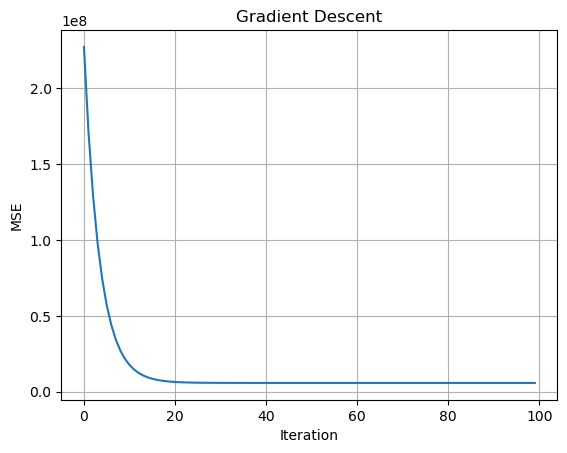

Last W: [879.26  81.08]
Last prediction: [52917.52 88249.92]
Real prices: [50000 90000]


In [7]:
## Let's see how MSE going down
import matplotlib.pyplot as plt
mse_history = []
for i in range(100):
  # 1st step: predict
  y_pred = np.dot(X, W) 

  # 2nd step: error
  error = y_pred - y

  # 3rd step: gradient
  gradient = np.dot(X.T, error)*(2/len(X))

  # 4th step: renewal of W
  W = W - learning_rate * gradient

  # observation of MSE
  mse = np.mean(error**2)
  mse_history.append(mse)

plt.plot(mse_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent")
plt.grid(True)
plt.show()

print(f"Last W: {W.round(2)}")
print(f"Last prediction: {y_pred.round(2)}")
print(f"Real prices: {y}")


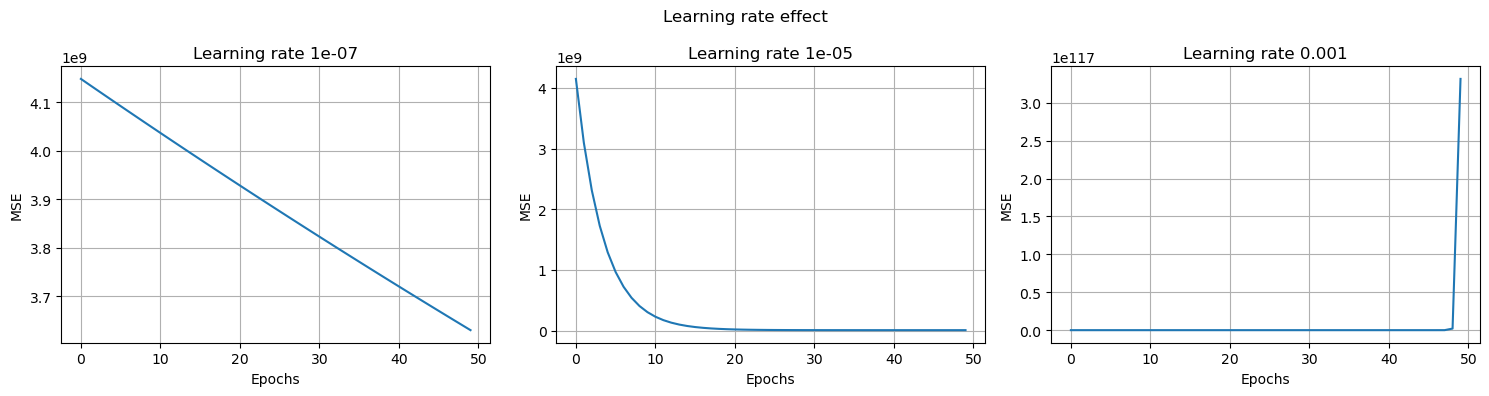

In [8]:
import numpy as np
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

X = np.array([[60, 2], [100, 4]])
y = np.array([50000, 90000])

for idx, lr in enumerate([0.0000001, 0.00001, 0.001]):
    W = np.array([100, 50])

    mse_list = []
    for i in range(50):
        y_pred = np.dot(X, W)
        error = y_pred - y
        gradient = (2 / len(X)) * np.dot(X.T, error)
        W = W - lr * gradient
        mse_list.append(np.mean(error ** 2))
    axes[idx].plot(mse_list)
    axes[idx].set_title("Learning rate {}".format(lr))
    axes[idx].set_xlabel("Epochs")
    axes[idx].set_ylabel("MSE")
    axes[idx].grid(True)
plt.suptitle("Learning rate effect")
plt.tight_layout()
plt.show()


In [11]:
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(max_iter=1000,
                        learning_rate='constant', 
                        eta0=0.00001,
                        random_state=42
                        )

X_train = np.array([[60, 2], [100, 4], [80, 3], [120, 4]])
y_train = np.array([50000, 90000, 70000, 95000])

# trying before scaling

sgd_model.fit(X_train, y_train) 
print("=== Predictions before scaling ===")
print("Weights: ", sgd_model.coef_)
print("Intercept(Bias): ", sgd_model.intercept_)
print("Predictions: ", sgd_model.predict(X_train))
print("Real prices: ", y_train)

=== Predictions before scaling ===
Weights:  [840.58196632  31.47372999]
Intercept(Bias):  [9.26229822]
Predictions:  [ 50507.12773749  84193.35385032  67350.24079391 101004.99317675]
Real prices:  [50000 90000 70000 95000]


In [16]:
# trying after scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
sgd_model_scaled = SGDRegressor(
    max_iter=1000,
    learning_rate="constant",
    eta0=0.01,  # Scaled inputs need a larger learning rate than 0.00001
    random_state=42,
)

# Fit the model on scaled features
sgd_model_scaled.fit(X_train_scaled, y_train)

# Make predictions using the scaled model

print("=== Predictions after scaling ===")
print("Weights: ", sgd_model_scaled.coef_)
print("Intercept(Bias): ", sgd_model_scaled.intercept_)
print("Predictions: ", sgd_model_scaled.predict(X_train_scaled))
print("Real prices: ", y_train)

=== Predictions after scaling ===
Weights:  [ 5953.82308575 12071.84348554]
Intercept(Bias):  [76249.64579157]
Predictions:  [50062.76509983 89831.66970329 69947.21740156 95156.93096159]
Real prices:  [50000 90000 70000 95000]


c:\Users\OsiyoComputers\anaconda\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
